In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

df.columns = df.columns.str.strip().str.lower()

cols_to_drop =['PassengerId','	Survived','	Pclass','	Name','	Sex','	Age','	SibSp','	Parch','	Ticket','	Fare','	Cabin','	Embarked'
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df['name'] = df['name'].fillna('Unknown')

df = df[(df['fare'] >= 10) & (df['fare'] <= 1000)]

print("Columns currently in your data:", df.columns.tolist())


Columns currently in your data: ['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


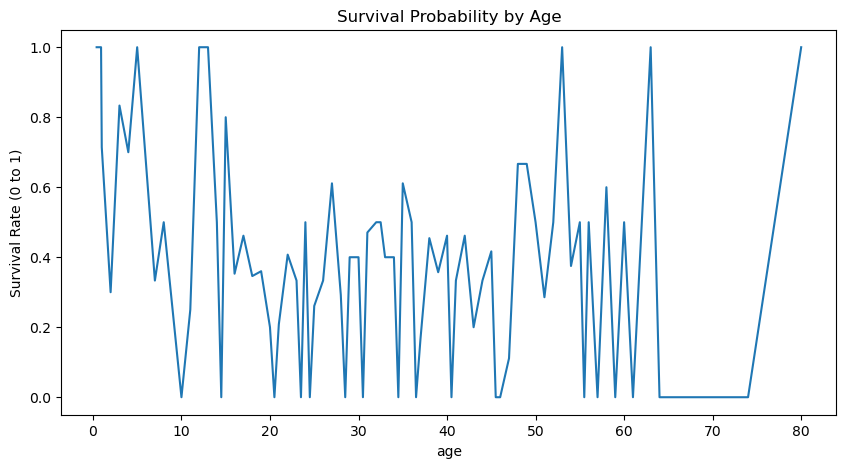

In [9]:
df = sns.load_dataset('titanic')

df['age'] = df['age'].fillna(df['age'].median())

plt.figure(figsize = (10, 5))
sns.lineplot(data = df, x = 'age', y = 'survived', errorbar = None)
plt.title('Survival Probability by Age')
plt.ylabel('Survival Rate (0 to 1)')
plt.show()

Insight: The survivors of the Titanic were mostly comprising youths, fewer middle-aged and slightly older men and women. It might have to do with the preservation of the younglings in order to continue their respective family businesses or preserve their bloodline or influence. Hence the peak for the children and teenagers and the gradual dip for middle-aged adults.

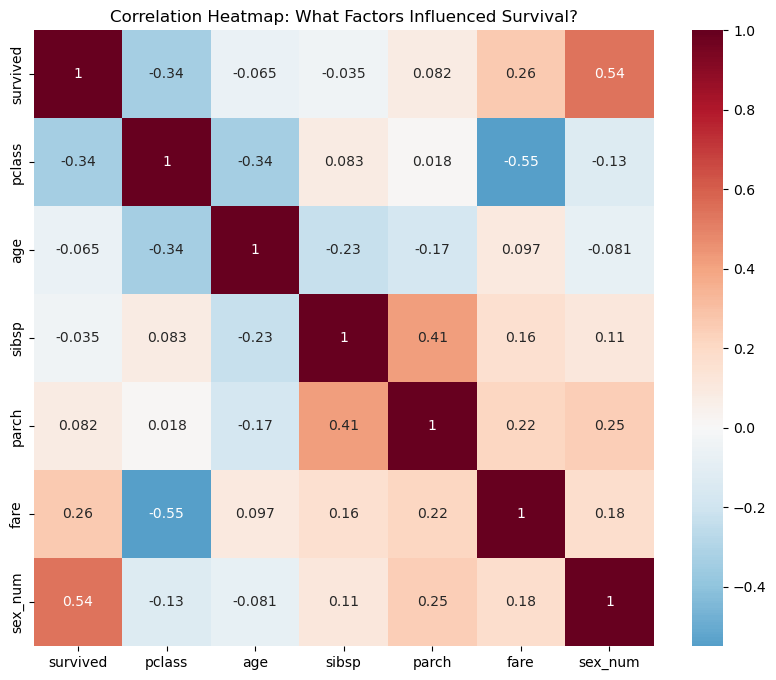

In [12]:
df['sex_num'] = df['sex'].map({'male':0, 'female': 1})

plt.figure(figsize = (10, 8))
corr = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_num']].corr()
sns.heatmap(corr, annot = True, cmap = 'RdBu_r', center = 0)
plt.title('Correlation Heatmap: What Factors Influenced Survival?')
plt.show()

Insight : It quickly shows that Pclass and Fare have a strong negative correlation (lower class number = higher fare), and Sex has a very high correlation with survival.

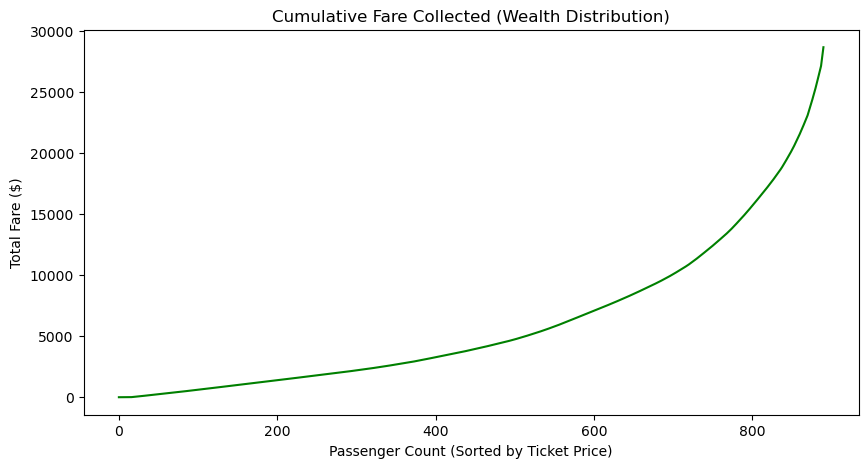

In [14]:
df_sorted = df.sort_values('fare').reset_index()
df_sorted['cumulative_fare'] = df_sorted['fare'].cumsum()

plt.figure(figsize = (10, 5))
plt.plot(df_sorted.index, df_sorted['cumulative_fare'], color = 'green')
plt.title('Cumulative Fare Collected (Wealth Distribution)')
plt.xlabel('Passenger Count (Sorted by Ticket Price)')
plt.ylabel('Total Fare ($)')
plt.show()

Insight: THis shows that a small percentage of 1st-class passengers contributed massively in the titanic's toal reven